In [ ]:
!pip install pillow transformers torch

In [ ]:
from urllib.request import urlopen
from PIL import Image
from transformers import CLIPTokenizerFast, CLIPProcessor, CLIPModel

# 加载一张小狗在雪地里玩耍的AI生成的图像
puppy_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/puppy.png"
image = Image.open(urlopen(puppy_path)).convert("RGB")

caption = "a puppy playing in the snow"

# 加载CLIP核心组件
model_id = "openai/clip-vit-base-patch32"

# 加载分词器来预处理文本
clip_tokenizer = CLIPTokenizerFast.from_pretrained(model_id)

# 加载预处理器来预处理图像
clip_processor = CLIPProcessor.from_pretrained(model_id)

# 用于生成本文嵌入和图像嵌入的主模型
model = CLIPModel.from_pretrained(model_id)

# 对输入进行分词
inputs = clip_tokenizer(caption, return_tensors="pt")
print("分词结果：")
print(inputs)

# 将输入ID转换为对应的词元
tokens = clip_tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print("\n对应的词元：")
print(tokens)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


分词结果：
{'input_ids': tensor([[49406,   320,  6829,  1629,   530,   518,  2583, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}

对应的词元：
['<|startoftext|>', 'a</w>', 'puppy</w>', 'playing</w>', 'in</w>', 'the</w>', 'snow</w>', '<|endoftext|>']


In [ ]:
text_embedding = model.get_text_features(**inputs)

# 提取池化后的张量，然后查看它的形状
pooled_embedding = text_embedding.pooler_output
print(pooled_embedding.shape)
# 预期输出类似于: torch.Size([batch_size, hidden_size])

torch.Size([1, 512])


In [ ]:
# 预处理图像
processed_image = clip_processor(
    text=None, images=image, return_tensors="pt"
)["pixel_values"]
processed_image.shape

torch.Size([1, 3, 224, 224])

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

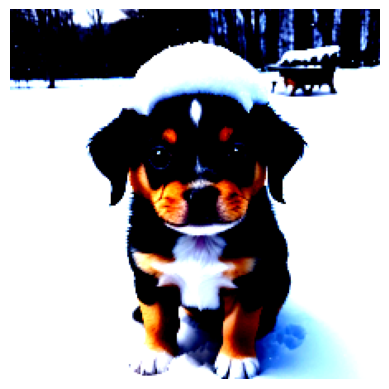

In [ ]:
img = processed_image.squeeze(0)
img = img.permute(*torch.arange(img.ndim - 1, -1, -1))
# 修复：将 "ijk->jlk" 改为 "ijk->jik"，即交换第 0 和第 1 维
img = np.einsum("ijk->jik", img)

# 可视化预处理后的图像
plt.imshow(img)
plt.axis("off")

In [ ]:
# 获取模型输出对象
image_outputs = model.get_image_features(processed_image)

# 提取池化后的张量并查看形状
image_embedding = image_outputs.pooler_output
print(image_embedding.shape)
# 预期输出类似于: torch.Size([batch_size, hidden_size])

torch.Size([1, 512])


In [ ]:
# 1. 重新从模型获取特征（使用 raw_ 前缀来存放“大包裹”对象，避免变量名冲突）
raw_text_output = model.get_text_features(**inputs)
raw_image_output = model.get_image_features(processed_image)

# 2. 从包裹中提取真正的 Tensor
# （注：如果这里提示找不到 pooler_output，请把下面两行分别换成 raw_text_output[0] 和 raw_image_output[0]）
text_tensor = raw_text_output.pooler_output
image_tensor = raw_image_output.pooler_output

# 3. 对提取出来的 Tensor 进行 L2 归一化处理
text_tensor = text_tensor / text_tensor.norm(dim=-1, keepdim=True)
image_tensor = image_tensor / image_tensor.norm(dim=-1, keepdim=True)

# 4. 转移到 CPU 并转换为 NumPy 数组，准备计算相似度
text_array = text_tensor.detach().cpu().numpy()
image_array = image_tensor.detach().cpu().numpy()

print("搞定！文本特征形状:", text_array.shape)
print("搞定！图像特征形状:", image_array.shape)

搞定！文本特征形状: (1, 512)
搞定！图像特征形状: (1, 512)


In [ ]:
# 使用前面步骤生成的 NumPy 数组进行计算
score = np.dot(text_array, image_array.T)

# 或者在 Python 里有一种更优雅的矩阵乘法简写：
# score = text_array @ image_array.T

print("图文匹配余弦相似度:", score)

图文匹配余弦相似度: [[0.33146897]]


In [ ]:
from sentence_transformers import SentenceTransformer, util
from PIL import Image
import requests

# 1. 加载模型
model = SentenceTransformer("clip-ViT-B-32")

# 2. 定义你要测试的图片 (images)
# 这里用一张网上的小狗照片做演示，你也可以换成本地路径比如 Image.open("my_photo.jpg")
img_url = "https://images.unsplash.com/photo-1530281700549-e82e7bf110d6?w=300"
image = Image.open(requests.get(img_url, stream=True).raw)
images = [image] # 注意：encode 方法通常接收一个列表

# 3. 定义你要对比的描述文本 (captions)
captions = [
    "a photo of a cute dog",
    "a photo of a cat",
    "a picture of a sports car"
]

# 4. 一键编码！(它在底层自动帮你做好了预处理、特征提取、转 Tensor 和 L2归一化)
image_embeddings = model.encode(images)
text_embeddings = model.encode(captions)

# 5. 计算余弦相似度矩阵
sim_matrix = util.cos_sim(image_embeddings, text_embeddings)

print("相似度得分矩阵:\n", sim_matrix)

modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: /root/.cache/huggingface/hub/models--sentence-transformers--clip-ViT-B-32/snapshots/327ab6726d33c0e22f920c83f2ff9e4bd38ca37f/0_CLIPModel
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


相似度得分矩阵:
 tensor([[0.2800, 0.2121, 0.2002]])


In [1]:
from transformers import AutoProcessor, Blip2ForConditionalGeneration
import torch
from PIL import Image
import urllib.request # 导入 urllib.request

# 加载处理器和主模型
blip_processor = AutoProcessor.from_pretrained("Salesforce/blip2-opt-2.7b")
model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16
)

# 将模型发送到GPU以加速推理
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# 加载跑车图像
car_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/car.png"

# 使用 urllib.request.urlopen 获取图像数据流
image = Image.open(urllib.request.urlopen(car_path)).convert("RGB")

print("图像加载成功，尺寸为:", image.size)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

图像加载成功，尺寸为: (492, 520)


In [3]:
inputs = blip_processor(image, return_tensors="pt").to(device, torch.float16)
pixel_values = inputs["pixel_values"]


# 文本预处理
blip_processor.tokenizer

# 预处理文本
text = "My vocation was remarkably melodic"
token_ids = blip_processor(image, text=text, return_tensors="pt")
token_ids = token_ids.to(device, torch.float16).input_ids[0]

# 将输入ID转换回词元
tokens = blip_processor.tokenizer.convert_ids_to_tokens(token_ids)
tokens = [token.replace("▁", "_") for token in tokens]
# 以跑车的图像为例，通过图像处理器将其转换为符合模型输入要求的张量矩阵
# （延续前文的car_path和image变量，此处为图像预处理步骤）
inputs = blip_processor(image, return_tensors="pt").to(device, torch.float16)

# 下一步是使用BLIP-2模型将图像转换为词元ID，随后，我们可将这些词元ID进一步转换
# 为对应的文本描述，即通过模型生成的图像语义表示：
# 为图像生成候选的词元ID（词汇的ID）
generated_ids = model.generate(**inputs, max_new_tokens=20)
# 从词元ID生成文本
generated_text = blip_processor.batch_decode(
    generated_ids, skip_special_tokens=True
)[0]
generated_text = generated_text.strip()
# 替换为 Hugging Face 常用的稳定测试图片 (COCO数据集的猫)
url = "http://images.cocodataset.org/val2017/000000039769.jpg"

# 这个链接通常不需要复杂的伪装，但保留 Headers 也是个好习惯
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
image = Image.open(urllib.request.urlopen(req)).convert("RGB")

# 生成描述语
inputs = blip_processor(image, return_tensors="pt").to(device, torch.float16)
generated_ids = model.generate(**inputs, max_new_tokens=20)
generated_text = blip_processor.batch_decode(
    generated_ids, skip_special_tokens=True
)[0]
generated_text = generated_text.strip()
image = Image.open(urllib.request.urlopen(car_path)).convert("RGB")

# 视觉问答
prompt = "Question: Write down what you see in this picture. Answer:"

# 同时处理图像和提示词
inputs = blip_processor(image, text=prompt, return_tensors="pt").to(device, torch.float16)

# 生成文本
generated_ids = model.generate(**inputs, max_new_tokens=30)
generated_text = blip_processor.batch_decode(
    generated_ids, skip_special_tokens=True
)
generated_text = generated_text[0].strip()
generated_text

# 类聊天式提示词
prompt = "Question: Write down what you see in this picture. Answer: A sports car driving on the road at sunset. Question: What would it cost me to drive that car? Answer:"

# 生成输出
inputs = blip_processor(image, text=prompt, return_tensors="pt").to(device, torch.float16)
generated_ids = model.generate(**inputs, max_new_tokens=30)
generated_text = blip_processor.batch_decode(
    generated_ids, skip_special_tokens=True
)
generated_text = generated_text[0].strip()
generated_text

from IPython.display import HTML, display
import ipywidgets as widgets

# 提前初始化组件，以便捕获报错
output = widgets.Output()
memory = []

@output.capture()  # 【关键】：将隐藏的报错信息强行打印到屏幕上
def text_eventhandler(*args):
    question = args[0]["new"]
    if not question:
        return
    args[0]["owner"].value = ""

    # 1. 创建提示词
    if not memory:
        prompt = "Question: " + question + " Answer:"
    else:
        template = "Question: {} Answer: {}."
        prompt = " ".join(
            [template.format(m[0], m[1]) for m in memory]
        ) + " Question: " + question + " Answer:"

    # 2. 生成文本
    inputs = blip_processor(image, text=prompt, return_tensors="pt").to(device, torch.float16)
    generated_ids = model.generate(**inputs, max_new_tokens=100)
    generated_text_raw = blip_processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    # 3. 【核心修复】：更安全的文本清理逻辑
    generated_text = generated_text_raw.strip()

    # 如果模型复读了整段提示词，先把提示词剔除
    if prompt in generated_text:
        generated_text = generated_text.replace(prompt, "")
    elif generated_text.startswith("Question:"):
        # 备用防误杀方案
        generated_text = generated_text.split("Answer:")[-1]

    # 防止模型自己产生幻觉问下一个问题
    generated_text = generated_text.split("Question")[0].strip()

    # 4. 终极防线：如果还是空，打印原始输出供我们排查
    if not generated_text:
        generated_text = f"[调试] 模型返回了空白。它的原始输出是: '{generated_text_raw}'"

    # 5. 更新记忆并输出
    memory.append((question, generated_text))
    output.append_display_data(HTML("<b>USER:</b> " + question))
    output.append_display_data(HTML("<b>BLIP-2:</b> " + generated_text))
    output.append_display_data(HTML("<br>"))

# 准备组件
in_text = widgets.Text()
in_text.continuous_update = False
in_text.observe(text_eventhandler, "value")

# 显示聊天框
display(
    widgets.VBox(
        children=[output, in_text],
        layout=widgets.Layout(display="inline-flex", flex_flow="column-reverse"),
    )
)